In [1]:
import os
import numpy as np
import torch

try:
    import igraph as ig
except ImportError as e:
    raise ImportError(
        "需要安装 python-igraph 库才能运行层次聚类部分；"
        "请执行：pip install igraph"
    ) from e


############################
# 0. 已有接口（稍作补全）
############################

def get_edges(dataset, ratio):
    """
    从 split_dict_{ratio}.pt 中读取 train/test 正负边。

    返回：
        train_edges: (E_train, 2) np.ndarray[int64]
        test_pos_edges: (E_pos, 2) np.ndarray[int64]
        test_neg_edges: (E_neg, 2) np.ndarray[int64]
    """
    if dataset == 'icews18_max':
        path = f"/home/gaochi/leaf_matching/datasets/icews18/split_max/split_dict_{ratio}.pt"
    else:
        path = f"/home/gaochi/leaf_matching/datasets/{dataset}/split/split_dict_{ratio}.pt"
    data = torch.load(path)
    train_edges = data["train"]["edge"].numpy()
    test_pos_edges = data["test"]["edge"].numpy()
    test_neg_edges = data["test"]["edge_neg"].numpy()
    return train_edges, test_pos_edges, test_neg_edges


def get_scores(alg_path, dataset, ratio, seed):
    """
    从已有 logs 中读取对应 (alg, dataset, ratio, seed) 的正负样本得分。

    返回：
        scores_pos: (E_pos,) np.ndarray[float]
        scores_neg: (E_neg,) np.ndarray[float]
        若找不到文件，则 (None, None)
    """
    possible_format = [
        "s{seed}-r{ratio}",
        "s{seed}_r{ratio}",
        "r{ratio}_s{seed}",
        "r{ratio}-s{seed}",
    ]

    for fmt in possible_format:
        cur_fmt = fmt.format(seed=seed, ratio=ratio)
        pos_path = f"{alg_path}/{dataset}/scores/{cur_fmt}/pos.npy"
        neg_path = f"{alg_path}/{dataset}/scores/{cur_fmt}/neg.npy"
        try:
            scores_pos = np.load(pos_path)
            scores_neg = np.load(neg_path)
            return scores_pos, scores_neg
        except FileNotFoundError:
            continue

    return None, None

############################
# 1. 图构建与层次模块化聚类
############################

def build_graph_for_clustering(train_edges, num_nodes, directed=False):
    """
    将 train_edges 转为 igraph.Graph，用于社区检测。

    参数：
        train_edges: (E_train, 2) np.ndarray[int]
        num_nodes: int，节点数
        directed: bool，是否构造有向图（这里默认无向）

    返回：
        g: igraph.Graph
    """
    # igraph 默认顶点编号为 0..n-1
    g = ig.Graph(
        n=int(num_nodes),
        edges=[(int(u), int(v)) for u, v in train_edges],
        directed=directed,
    )
    # 如果需要可以简化多重边、自环
    g.simplify(combine_edges=None)
    return g


def _extract_levels_from_multilevel_result(res, num_nodes):
    """
    兼容不同版本 igraph.community_multilevel 的返回格式。

    目标：
        返回 levels: List[np.ndarray]，每个元素为长度 num_nodes 的 membership 向量。

    可能情况：
        1) res 是 list[VertexClustering] (Graph.community_multilevel(return_levels=True))
        2) res 是 (list_of_memberships, modularities) (GraphBase.community_multilevel)
        3) res 是单一 VertexClustering (return_levels=False) ——不在本函数正常调用路径内
    """
    levels = []

    # 情况 1：list of VertexClustering
    if isinstance(res, list):
        if len(res) == 0:
            return levels
        if hasattr(res[0], "membership"):
            for vc in res:
                mem = np.asarray(vc.membership, dtype=np.int64)
                assert mem.shape[0] == num_nodes
                levels.append(mem)
            return levels

    # 情况 2：tuple (memberships, modularities)
    if isinstance(res, tuple) and len(res) >= 1:
        memberships = res[0]
        # 可能是 list[list[int]]
        if isinstance(memberships, list):
            for mem in memberships:
                mem_arr = np.asarray(mem, dtype=np.int64)
                assert mem_arr.shape[0] == num_nodes
                levels.append(mem_arr)
            return levels

    # 情况 3：单一 VertexClustering
    if hasattr(res, "membership"):
        mem = np.asarray(res.membership, dtype=np.int64)
        assert mem.shape[0] == num_nodes
        levels.append(mem)
        return levels

    raise RuntimeError("无法从 community_multilevel 的返回值中解析多层 membership。")


def run_hierarchical_community_detection(graph, method="louvain", resolution=1.0):
    """
    在给定图上执行层次模块化聚类，得到多层划分。

    参数：
        graph: igraph.Graph
        method: 当前只支持 "louvain" (multilevel)
        resolution: float, 模块度分辨率参数

    返回：
        levels: List[np.ndarray]，每个为长度 num_nodes 的 membership 向量
                约定 levels[0] 是较细的划分，levels[-1] 较粗。
    """
    num_nodes = graph.vcount()

    if method.lower() == "louvain":
        # python-igraph 0.9+ 的 Graph.community_multilevel
        # 注意：不同版本的返回格式不同，交给辅助函数统一解析
        res = graph.community_multilevel(return_levels=True, resolution=resolution)
        levels = _extract_levels_from_multilevel_result(res, num_nodes)
        # 保险起见，按照“从细到粗”的顺序排序：簇数多的视为“细”
        levels_sorted = sorted(levels, key=lambda mem: len(np.unique(mem)), reverse=True)
        return levels_sorted
    else:
        raise NotImplementedError(f"暂不支持方法: {method}")


############################
# 2. 从划分构造 module tree
############################

def build_module_tree_from_levels(levels):
    """
    根据多层 membership 构造 module tree。

    约定：
        - 输入 levels 为 List[np.ndarray]，每个为长度 N 的 membership 向量。
        - levels[0] 为最细层（簇数最多），levels[-1] 为最粗层。

    构造：
        - 叶子为原始节点（0..N-1）
        - level 0 的每个簇对应一个 module node，作为叶子的父节点
        - level l 的每个簇对应一个 module node，作为 level l-1 簇的父节点
        - 最顶层簇再连到一个全局 root

    返回：
        tree: dict，包含：
            - "parent": np.ndarray[int]，长度 num_tree_nodes
            - "depth": np.ndarray[int]
            - "leaf_to_tree": np.ndarray[int]，长度 N
    """
    if len(levels) == 0:
        raise ValueError("levels 不能为空。")

    num_nodes = levels[0].shape[0]
    for mem in levels:
        assert mem.shape[0] == num_nodes

    parent = []
    depth = []
    # 先加入 N 个叶子节点，对应原始节点
    leaf_to_tree = np.empty(num_nodes, dtype=np.int64)
    for v in range(num_nodes):
        node_id = len(parent)
        parent.append(-1)  # 先占位，之后再填充父节点
        depth.append(-1)   # 之后统一计算
        leaf_to_tree[v] = node_id

    # 每层簇 -> 对应的 tree node id
    # level_comm_to_tree[l][comm_internal_id] = tree_node_id
    level_comm_to_tree = []

    # 工具：对每层 membership 进行重编码为 0..C_l-1
    def _relabel_membership(mem):
        uniq = np.unique(mem)
        mapping = {old: idx for idx, old in enumerate(uniq)}
        mem_new = np.vectorize(mapping.get)(mem)
        return mem_new, len(uniq), mapping

    # level 0：让每个节点挂到对应的 level-0 module 上
    mem0, num_c0, mapping0 = _relabel_membership(levels[0])
    comm_to_node_0 = {}
    for c in range(num_c0):
        node_id = len(parent)
        parent.append(-1)  # 暂时没有父节点
        depth.append(-1)
        comm_to_node_0[c] = node_id
    level_comm_to_tree.append(comm_to_node_0)

    # 把叶子挂到 level 0 的模块
    for v in range(num_nodes):
        c = mem0[v]
        parent[leaf_to_tree[v]] = comm_to_node_0[c]

    # 为后续层准备一个“每个 level-簇 -> 任意代表节点”的映射
    # 用于找到其在上一层簇对应的上级簇
    def _build_comm_representatives(mem_relabel):
        # 对每个簇，找一个代表节点索引
        reps = {}
        for idx, c in enumerate(mem_relabel):
            if c not in reps:
                reps[c] = idx
        return reps  # c -> node_index

    comm_reps_prev = _build_comm_representatives(mem0)

    # 处理更高层 level 1..L-1
    prev_mem = mem0
    for lvl in range(1, len(levels)):
        mem_l, num_cl, mapping_l = _relabel_membership(levels[lvl])
        comm_to_node_l = {}
        # 为该层每个簇创建一个 module node
        for c in range(num_cl):
            node_id = len(parent)
            parent.append(-1)
            depth.append(-1)
            comm_to_node_l[c] = node_id

        # 对上一层的每个簇，建立 “上一层簇 -> 本层簇” 的父子关系
        comm_reps_l = _build_comm_representatives(mem_l)
        # 对上一层每个簇 c_prev：
        #   找到一个代表节点 v；该节点在本层 mem_l[v] = c_cur
        comm_to_node_prev = level_comm_to_tree[lvl - 1]
        for c_prev, repr_node in comm_reps_prev.items():
            c_cur = mem_l[repr_node]
            parent_node = comm_to_node_l[c_cur]
            child_node = comm_to_node_prev[c_prev]
            parent[child_node] = parent_node

        level_comm_to_tree.append(comm_to_node_l)
        comm_reps_prev = _build_comm_representatives(mem_l)
        prev_mem = mem_l

    # 最顶层 level = L-1 的所有簇，挂到一个全局 root
    root_id = len(parent)
    parent.append(-1)
    depth.append(0)  # root 深度为 0

    top_comm_to_node = level_comm_to_tree[-1]
    for c_top, node_top in top_comm_to_node.items():
        parent[node_top] = root_id

    # 现在 parent 已经完整，计算 depth
    parent = np.asarray(parent, dtype=np.int64)
    depth = np.asarray(depth, dtype=np.int64)

    # BFS/DFS 计算 depth
    children = [[] for _ in range(len(parent))]
    for node, p in enumerate(parent):
        if p >= 0:
            children[p].append(node)

    stack = [root_id]
    depth[root_id] = 0
    while stack:
        u = stack.pop()
        for v in children[u]:
            depth[v] = depth[u] + 1
            stack.append(v)

    tree = {
        "parent": parent,
        "depth": depth,
        "leaf_to_tree": leaf_to_tree,
        "root": root_id,
        "num_tree_nodes": len(parent),
        "num_leaves": num_nodes,
    }
    return tree


############################
# 3. 树距离 helper
############################

class TreeDistanceHelper:
    """
    提供 tree_distance(u, v) 接口。

    其中 u, v 均为原始图节点编号 [0, N-1]。
    """

    def __init__(self, tree):
        self.parent = tree["parent"]
        self.depth = tree["depth"]
        self.leaf_to_tree = tree["leaf_to_tree"]
        self.root = tree["root"]

    def _lca_tree_nodes(self, x, y):
        """
        在 tree 节点编号空间中求最近公共祖先。
        """
        depth = self.depth
        parent = self.parent

        # 先对齐深度
        while depth[x] > depth[y]:
            x = parent[x]
        while depth[y] > depth[x]:
            y = parent[y]
        # 一起向上
        while x != y:
            x = parent[x]
            y = parent[y]
        return x

    def tree_distance(self, u, v):
        """
        原始节点 u, v 的树距离：
            depth(u_node) + depth(v_node) - 2 * depth(LCA)
        """
        node_u = int(self.leaf_to_tree[int(u)])
        node_v = int(self.leaf_to_tree[int(v)])
        lca = self._lca_tree_nodes(node_u, node_v)
        return int(self.depth[node_u] + self.depth[node_v] - 2 * self.depth[lca])


def build_tree_distance_helper(tree):
    """
    根据 module tree 构造 TreeDistanceHelper。
    """
    return TreeDistanceHelper(tree)


############################
# 4. 对 test 边计算树距离 & 分 bin
############################

def compute_edge_tree_distances(test_pos_edges, test_neg_edges, dist_helper):
    """
    对 test 正负边计算树距离。

    输入：
        test_pos_edges: (E_pos, 2) np.ndarray[int]
        test_neg_edges: (E_neg, 2) np.ndarray[int]

    输出：
        pos_dists: (E_pos,) np.ndarray[int]
        neg_dists: (E_neg,) np.ndarray[int]
    """
    E_pos = test_pos_edges.shape[0]
    E_neg = test_neg_edges.shape[0]

    pos_dists = np.empty(E_pos, dtype=np.int32)
    neg_dists = np.empty(E_neg, dtype=np.int32)

    for i in range(E_pos):
        u, v = test_pos_edges[i]
        pos_dists[i] = dist_helper.tree_distance(u, v)

    for i in range(E_neg):
        u, v = test_neg_edges[i]
        neg_dists[i] = dist_helper.tree_distance(u, v)

    return pos_dists, neg_dists


def define_distance_bins(pos_dists, neg_dists, mode="default"):
    """
    定义 tree distance 的分 bin 规则。

    mode="default"：
        - bin1: d == 2
        - bin2: 3 <= d <= 4
        - bin3: d >= 5

    你可以根据实际树的深度自己改这个函数。

    返回：
        bins: List[dict]，每个 dict 至少包含：
            - "name": str
            - "min": int or None
            - "max": int or None
    """
    all_d = np.concatenate([pos_dists, neg_dists])
    if all_d.size == 0:
        raise ValueError("没有 test 边，无法定义距离分箱。")

    d_min, d_max = int(all_d.min()), int(all_d.max())

    if mode == "default":
        bins = []

        # d == 2
        if d_min <= 2 <= d_max:
            bins.append({"name": "d==2", "min": 2, "max": 2})

        # 3 <= d <= 4
        if d_max >= 3:
            upper = min(4, d_max)
            if upper >= 3:
                bins.append({"name": "d==3-4", "min": 3, "max": upper})

        # d >= 5
        if d_max >= 5:
            bins.append({"name": "d>=5", "min": 5, "max": None})

        if not bins:
            # fallback：单 bin，包含所有距离
            bins = [{"name": f"all_d[{d_min}-{d_max}]", "min": d_min, "max": d_max}]
        return bins

    else:
        raise NotImplementedError(f"暂不支持 mode={mode} 的自动分箱。")


def assign_edges_to_bins(pos_dists, neg_dists, bins):
    """
    根据 bins 对正负样本边进行分配。

    输入：
        pos_dists: (E_pos,)
        neg_dists: (E_neg,)
        bins: List[dict]，包含 "name"/"min"/"max"

    输出：
        pos_idx_by_bin: Dict[str, np.ndarray[int]]
        neg_idx_by_bin: Dict[str, np.ndarray[int]]
    """
    pos_idx_by_bin = {}
    neg_idx_by_bin = {}

    for b in bins:
        name = b["name"]
        dmin = b.get("min", None)
        dmax = b.get("max", None)

        cond_pos = np.ones_like(pos_dists, dtype=bool)
        cond_neg = np.ones_like(neg_dists, dtype=bool)

        if dmin is not None:
            cond_pos &= (pos_dists >= dmin)
            cond_neg &= (neg_dists >= dmin)
        if dmax is not None:
            cond_pos &= (pos_dists <= dmax)
            cond_neg &= (neg_dists <= dmax)

        pos_idx = np.where(cond_pos)[0]
        neg_idx = np.where(cond_neg)[0]

        pos_idx_by_bin[name] = pos_idx
        neg_idx_by_bin[name] = neg_idx

    return pos_idx_by_bin, neg_idx_by_bin


############################
# 5. 指标：AUC / AP
############################

def _compute_auc_from_scores(y_true, y_score):
    """
    手动计算二分类 AUC，使用 rank-based 公式：
        AUC = (sum_ranks_positive - P*(P+1)/2) / (P*N)

    y_true: (N,), {0,1}
    y_score: (N,)
    """
    y_true = np.asarray(y_true, dtype=np.int32)
    y_score = np.asarray(y_score, dtype=np.float64)

    N = y_true.shape[0]
    P = int(y_true.sum())
    N_neg = N - P
    if P == 0 or N_neg == 0:
        return np.nan

    # 计算 score 的排序名次（处理 ties：平均 rank）
    order = np.argsort(y_score)
    ranks = np.empty(N, dtype=np.float64)
    ranks[order] = np.arange(1, N + 1, dtype=np.float64)

    # 处理 ties：同分数取平均 rank
    # 先按排序后的 score 扫一遍
    sorted_scores = y_score[order]
    i = 0
    while i < N:
        j = i + 1
        while j < N and sorted_scores[j] == sorted_scores[i]:
            j += 1
        if j - i > 1:
            avg_rank = 0.5 * (i + 1 + j)
            ranks[order[i:j]] = avg_rank
        i = j

    sum_ranks_pos = float(ranks[y_true == 1].sum())
    auc = (sum_ranks_pos - P * (P + 1) / 2.0) / (P * N_neg)
    return auc


def _compute_average_precision(y_true, y_score):
    """
    手动计算 Average Precision (AP)。

    公式：
        AP = sum_k (P(k) * Δrecall(k))
    简化实现：按分数降序扫描。
    """
    y_true = np.asarray(y_true, dtype=np.int32)
    y_score = np.asarray(y_score, dtype=np.float64)

    N = y_true.shape[0]
    if N == 0:
        return np.nan
    P = int(y_true.sum())
    if P == 0:
        return np.nan

    order = np.argsort(-y_score)
    y_true_sorted = y_true[order]

    tp = 0
    fp = 0
    prev_recall = 0.0
    ap = 0.0

    for i in range(N):
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1
        recall = tp / P
        precision = tp / (tp + fp)
        if y_true_sorted[i] == 1:
            ap += precision * (recall - prev_recall)
            prev_recall = recall

    return ap


def compute_link_prediction_metrics(scores_pos, scores_neg):
    """
    给定正负样本分数，计算若干 link prediction 指标。

    返回：
        metrics: dict
            - "auc"
            - "ap"
    """
    scores_pos = np.asarray(scores_pos, dtype=np.float64)
    scores_neg = np.asarray(scores_neg, dtype=np.float64)

    y_true = np.concatenate([
        np.ones_like(scores_pos, dtype=np.int32),
        np.zeros_like(scores_neg, dtype=np.int32),
    ])
    y_score = np.concatenate([scores_pos, scores_neg])

    if y_true.size == 0:
        return {"auc": np.nan, "ap": np.nan}

    auc = _compute_auc_from_scores(y_true, y_score)
    ap = _compute_average_precision(y_true, y_score)

    return {
        "auc": float(auc),
        "ap": float(ap),
    }


def compute_metrics_by_tree_distance_bin(scores_pos, scores_neg,
                                         pos_idx_by_bin, neg_idx_by_bin):
    """
    在每个距离 bin 上分别计算指标。

    输入：
        scores_pos: (E_pos,)
        scores_neg: (E_neg,)
        pos_idx_by_bin, neg_idx_by_bin: Dict[str, np.ndarray]

    输出：
        metrics_by_bin: Dict[str, Dict[str, float]]
    """
    metrics_by_bin = {}

    for name in pos_idx_by_bin.keys():
        pos_idx = pos_idx_by_bin[name]
        neg_idx = neg_idx_by_bin[name]

        if pos_idx.size == 0 or neg_idx.size == 0:
            # 没有样本，指标置为 NaN
            metrics_by_bin[name] = {"auc": np.nan, "ap": np.nan}
            continue

        m = compute_link_prediction_metrics(
            scores_pos[pos_idx],
            scores_neg[neg_idx],
        )
        metrics_by_bin[name] = m

    return metrics_by_bin


############################
# 6. 树构建缓存：per-dataset
############################

def get_or_build_hierarchy_tree(dataset, edges, cache_dir,
                                method="louvain", resolution=1.0):
    """
    若存在缓存的 module tree 则加载，否则构建并缓存。

    说明：
        - 为简单起见，这里使用当前传入的 edges 来构建社区结构。
          若你希望基于“全集图”构建，可自行在外部先生成一个 global_edges 传进来。

    输入：
        dataset: str
        edges: (E_train, 2) np.ndarray[int]
        cache_dir: str
        method: "louvain"
        resolution: float

    输出：
        tree: dict
    """
    os.makedirs(cache_dir, exist_ok=True)
    cache_path = os.path.join(cache_dir, f"{dataset}_tree.npz")

    if os.path.exists(cache_path):
        data = np.load(cache_path, allow_pickle=True)
        tree = {
            "parent": data["parent"],
            "depth": data["depth"],
            "leaf_to_tree": data["leaf_to_tree"],
            "root": int(data["root"]),
            "num_tree_nodes": int(data["num_tree_nodes"]),
            "num_leaves": int(data["num_leaves"]),
        }
        return tree

    # 构建 graph
    num_nodes = int(edges.max()) + 1
    g = build_graph_for_clustering(edges, num_nodes, directed=False)
    levels = run_hierarchical_community_detection(
        g, method=method, resolution=resolution
    )
    tree = build_module_tree_from_levels(levels)

    # 缓存到磁盘
    np.savez(
        cache_path,
        parent=tree["parent"],
        depth=tree["depth"],
        leaf_to_tree=tree["leaf_to_tree"],
        root=tree["root"],
        num_tree_nodes=tree["num_tree_nodes"],
        num_leaves=tree["num_leaves"],
    )
    return tree


############################
# 7. 单次 (dataset, ratio, alg, seed) 层次评估
############################

def evaluate_one_setting_hierarchical(dataset, ratio, alg, seed,
                                      alg_path, tree, dist_helper,
                                      distance_bins_mode="default"):
    """
    在单个 (dataset, ratio, alg, seed) 上进行层次模块化评估。

    输入：
        dataset: str
        ratio: float
        alg: str
        seed: int
        alg_path: str
        tree: dict
        dist_helper: TreeDistanceHelper
        distance_bins_mode: str

    输出：
        result: dict，包含：
            - "global": dict (AUC/AP)
            - "by_distance_bin": Dict[str, Dict[str, float]]
    """
    # 1. 读取 edges
    train_edges, test_pos_edges, test_neg_edges = get_edges(dataset, ratio)

    # 2. 读取 scores
    scores_pos, scores_neg = get_scores(alg_path, dataset, ratio, seed=seed)
    if scores_pos is None or scores_neg is None:
        print(f"[WARN] Skipping {alg}, {dataset}, ratio={ratio} (scores missing).")
        return None

    # 检查形状一致性
    if scores_pos.shape[0] != test_pos_edges.shape[0]:
        print(f"[WARN] pos scores size != test_pos_edges for {alg}, {dataset}, ratio={ratio}")
    if scores_neg.shape[0] != test_neg_edges.shape[0]:
        print(f"[WARN] neg scores size != test_neg_edges for {alg}, {dataset}, ratio={ratio}")

    # 3. 全局指标
    global_metrics = compute_link_prediction_metrics(scores_pos, scores_neg)

    # 4. 计算树距离
    pos_dists, neg_dists = compute_edge_tree_distances(
        test_pos_edges, test_neg_edges, dist_helper
    )

    # 5. 定义分箱 & 分配
    bins = define_distance_bins(pos_dists, neg_dists, mode=distance_bins_mode)
    pos_idx_by_bin, neg_idx_by_bin = assign_edges_to_bins(pos_dists, neg_dists, bins)

    # 6. 分 bin 指标
    metrics_by_bin = compute_metrics_by_tree_distance_bin(
        scores_pos, scores_neg,
        pos_idx_by_bin, neg_idx_by_bin
    )

    result = {
        "global": global_metrics,
        "by_distance_bin": metrics_by_bin,
    }
    return result



In [2]:
# ============================
# 9. 层次结构可视化工具
# ============================

import matplotlib.pyplot as plt


def compute_subtree_sizes(tree):
    """
    计算每个树节点的子树大小（包含多少个叶子）。

    输入：
        tree: dict，来自 build_module_tree_from_levels 的输出

    返回：
        subtree_size: np.ndarray[int]，长度 num_tree_nodes
                      subtree_size[u] = 该节点 u 的子树中包含的叶子数量
    """
    parent = tree["parent"]
    num_nodes = tree["num_tree_nodes"]
    num_leaves = tree["num_leaves"]

    # children 列表
    children = [[] for _ in range(num_nodes)]
    for v, p in enumerate(parent):
        if p >= 0:
            children[p].append(v)

    subtree_size = np.zeros(num_nodes, dtype=np.int64)

    # 后序 DFS 计算子树大小
    root = tree["root"]
    stack = [(root, 0)]  # (node, state)  state=0: 先序, state=1: 后序
    order = []

    while stack:
        u, st = stack.pop()
        if st == 0:
            stack.append((u, 1))
            for v in children[u]:
                stack.append((v, 0))
        else:
            # 叶子：如果是原始叶子（0..num_leaves-1），大小为 1
            if u < num_leaves:
                subtree_size[u] = 1
            else:
                s = 0
                for v in children[u]:
                    s += subtree_size[v]
                subtree_size[u] = s
            order.append(u)

    return subtree_size


def compute_leaf_order(tree):
    """
    通过 DFS 从 root 出发，得到叶子的一个线性顺序，
    并返回 leaf_node -> 位置 的映射。

    输入：
        tree: dict

    返回：
        leaf_order: np.ndarray[int]，长度 num_leaves，
                    按照 DFS 顺序列出叶子对应的 tree 节点编号
        leaf_pos: np.ndarray[int]，长度 num_tree_nodes，
                  对于叶子节点 u (< num_leaves)，leaf_pos[u] 为其在线性顺序中的位置；
                  非叶子节点的值为 -1。
    """
    parent = tree["parent"]
    num_nodes = tree["num_tree_nodes"]
    num_leaves = tree["num_leaves"]
    root = tree["root"]

    children = [[] for _ in range(num_nodes)]
    for v, p in enumerate(parent):
        if p >= 0:
            children[p].append(v)

    leaf_order_list = []

    # 简单 DFS：root -> children
    stack = [root]
    while stack:
        u = stack.pop()
        # 逆序入栈以保持子节点顺序可控（无特别需求可以不逆序）
        cs = children[u]
        for v in reversed(cs):
            stack.append(v)

        # 如果是叶子（原始节点），加入 leaf_order
        if u < num_leaves:
            leaf_order_list.append(u)

    leaf_order = np.array(leaf_order_list, dtype=np.int64)
    assert leaf_order.shape[0] == num_leaves

    leaf_pos = np.full(num_nodes, -1, dtype=np.int64)
    for idx, u in enumerate(leaf_order):
        leaf_pos[u] = idx

    return leaf_order, leaf_pos


def compute_module_spans(tree, leaf_pos):
    """
    计算每个树节点在一维坐标上的 [x_min, x_max] 范围，
    即该节点子树中所有叶子的位置范围。

    输入：
        tree: dict
        leaf_pos: np.ndarray[int]，compute_leaf_order 的返回值之一

    返回：
        spans: np.ndarray[float], 形状 (num_tree_nodes, 2)，
               spans[u, 0] = x_min, spans[u, 1] = x_max
               对于没有叶子后代的节点（理论上不应出现），范围为 (inf, -inf)
    """
    parent = tree["parent"]
    num_nodes = tree["num_tree_nodes"]
    num_leaves = tree["num_leaves"]
    root = tree["root"]

    children = [[] for _ in range(num_nodes)]
    for v, p in enumerate(parent):
        if p >= 0:
            children[p].append(v)

    spans = np.zeros((num_nodes, 2), dtype=np.float64)
    spans[:, 0] = np.inf
    spans[:, 1] = -np.inf

    # 后序 DFS，先处理子，再回填父
    stack = [(root, 0)]
    post_order = []

    while stack:
        u, st = stack.pop()
        if st == 0:
            stack.append((u, 1))
            for v in children[u]:
                stack.append((v, 0))
        else:
            post_order.append(u)

    for u in post_order:
        if u < num_leaves:
            # 叶子：其范围即自身位置
            x = leaf_pos[u]
            spans[u, 0] = x
            spans[u, 1] = x
        else:
            # 内部节点：聚合子节点范围
            if not children[u]:
                # 没有子节点（异常情况），保持 inf/-inf
                continue
            x_min = np.inf
            x_max = -np.inf
            for v in children[u]:
                x_min = min(x_min, spans[v, 0])
                x_max = max(x_max, spans[v, 1])
            spans[u, 0] = x_min
            spans[u, 1] = x_max

    return spans


def visualize_module_tree_segments(
    tree,
    depth_min=1,
    depth_max=None,
    min_size=1,
    skip_leaves=True,
    figsize=(12, 4),
    ax=None,
):
    """
    用“线段树”式可视化层次模块化结果：
        - x 轴：叶子顺序（原始节点），每个叶子长度视为 1
        - y 轴：树的深度（可以理解为层级）
        - 每个模块节点画一条水平线段，[x_min, x_max]

    参数：
        tree: dict，module tree
        depth_min: int，最小可视化深度（>=1 可跳过 root）
        depth_max: int 或 None，最大可视化深度；None 时取树最大深度
        min_size: int，子树大小小于该值的模块不画，避免太碎
        skip_leaves: bool，是否跳过叶子节点（一般为 True）
        figsize: tuple，图像大小
        ax: matplotlib.axes.Axes 或 None；若为 None 则新建一个图

    返回：
        ax: matplotlib.axes.Axes
    """
    import numpy as np

    parent = tree["parent"]
    depth = tree["depth"]
    num_nodes = tree["num_tree_nodes"]
    num_leaves = tree["num_leaves"]

    # 计算子树大小
    subtree_size = compute_subtree_sizes(tree)

    # 计算叶子顺序和位置
    leaf_order, leaf_pos = compute_leaf_order(tree)

    # 计算每个节点的 [x_min, x_max]
    spans = compute_module_spans(tree, leaf_pos)

    # 深度范围
    if depth_max is None:
        depth_max = int(depth.max())

    # 准备画图
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # 为了让 root 在上、叶子在下，可以翻转 y 轴方向
    max_d = depth_max

    for u in range(num_nodes):
        d = depth[u]
        if d < depth_min or d > depth_max:
            continue
        if skip_leaves and u < num_leaves:
            continue
        if subtree_size[u] < min_size:
            continue

        x_min, x_max = spans[u]
        if not np.isfinite(x_min) or not np.isfinite(x_max):
            continue

        # 简单画条水平线，线长 ~ 子树叶子数
        y = max_d - d  # 让深度大的在下方
        ax.hlines(y=y, xmin=x_min, xmax=x_max, linewidth=1.0)

    ax.set_xlabel("Leaf index (DFS order)")
    ax.set_ylabel("Tree depth (inverted)")
    ax.set_ylim(-1, max_d - depth_min + 2)
    ax.set_xlim(-1, num_leaves)
    ax.set_title("Hierarchical modules (segment view)")

    # 可选：网格辅助读数
    ax.grid(True, axis="x", linestyle=":", linewidth=0.5)
    ax.grid(False, axis="y")

    return ax


def visualize_level_size_distribution(tree, figsize=(6, 4), ax=None):
    """
    可视化每个深度层上的模块子树大小分布（箱线图形式）。

    这可以辅助你判断“在哪一层的模块是结构化的、粒度合适的”。

    输入：
        tree: dict
        figsize: tuple
        ax: matplotlib.axes.Axes 或 None

    返回：
        ax
    """
    import numpy as np

    depth = tree["depth"]
    num_nodes = tree["num_tree_nodes"]

    subtree_size = compute_subtree_sizes(tree)

    max_d = int(depth.max())
    # 按深度收集模块大小（可以选择只看内部节点）
    depth_sizes = []
    labels = []
    for d in range(max_d + 1):
        idx = np.where(depth == d)[0]
        if idx.size == 0:
            continue
        sizes = subtree_size[idx]
        depth_sizes.append(sizes)
        labels.append(str(d))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    ax.boxplot(depth_sizes, labels=labels, showfliers=False)
    ax.set_xlabel("Tree depth")
    ax.set_ylabel("Subtree size (number of leaves)")
    ax.set_title("Subtree size distribution per depth")

    return ax


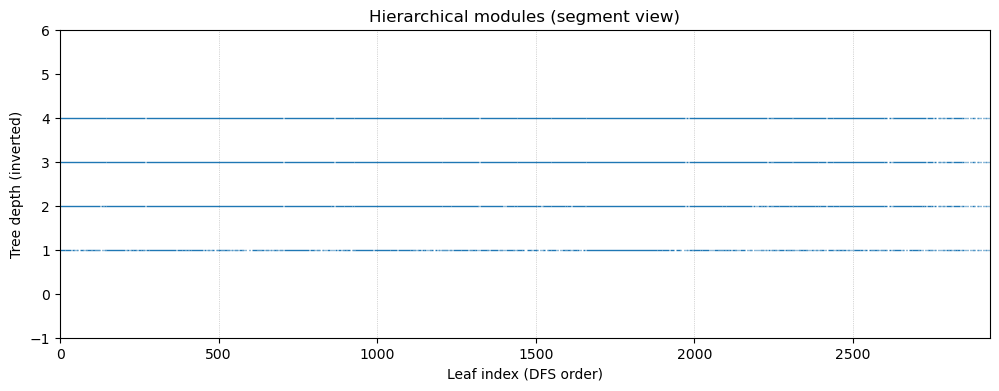

层次模块化评估完成，共有结果条目： 0


In [3]:
algorithms = ["nerd", "node2ket", "headnet", "ours_oi"]
datasets = ["cora_ml"] # , "cora", "citeseer", "pubmed"]
split_ticks = [0.9]
seed = 1

alg_path_map = {
    "ours_oi": "/home/gaochi/leaf_matching/logs_oi",
    "nerd": "/home/gaochi/LF_baseline/nerd/logs",
    "node2ket": "/home/gaochi/LF_baseline/any2ket_pybind/logs",
    "headnet": "/home/gaochi/LF_baseline/HEADNET/logs",
}

cache_dir = "/home/gaochi/leaf_matching/hierarchy_cache"

all_results_hier = {}

for dataset in datasets:
    for ratio in split_ticks:
        # 为构建 tree 读取 edges
        edges, test_pos_edges, _ = get_edges(dataset, ratio)
        tree = get_or_build_hierarchy_tree(
            dataset=dataset,
            edges=np.concatenate([edges, test_pos_edges], axis=0),
            cache_dir=cache_dir,
            method="louvain",
            resolution=1.0,
        )
        dist_helper = build_tree_distance_helper(tree)

        ax = visualize_module_tree_segments(
            tree,
            depth_min=1,
            depth_max=None,   # 或者具体数字，比如 6
            min_size=1,      # 子树叶子数 < 10 的模块不画
            skip_leaves=True,
            figsize=(12, 4),
        )
        plt.show()
    
        # for alg in algorithms:
        #     alg_path = alg_path_map[alg]
        #     res = evaluate_one_setting_hierarchical(
        #         dataset=dataset,
        #         ratio=ratio,
        #         alg=alg,
        #         seed=seed,
        #         alg_path=alg_path,
        #         tree=tree,
        #         dist_helper=dist_helper,
        #         distance_bins_mode="default",
        #     )
        #     if res is None:
        #         continue
        #     all_results_hier[(alg, dataset, ratio)] = res

# 你可以在这里把 all_results_hier 存盘或画图
# 例如：
# np.save("all_results_hier.npy", all_results_hier, allow_pickle=True)
print("层次模块化评估完成，共有结果条目：", len(all_results_hier))

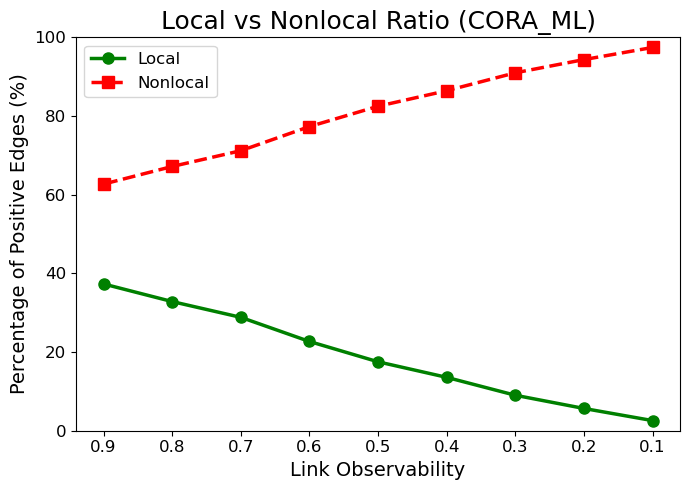

[INFO] Saved: cora_ml_local_ratio.pdf


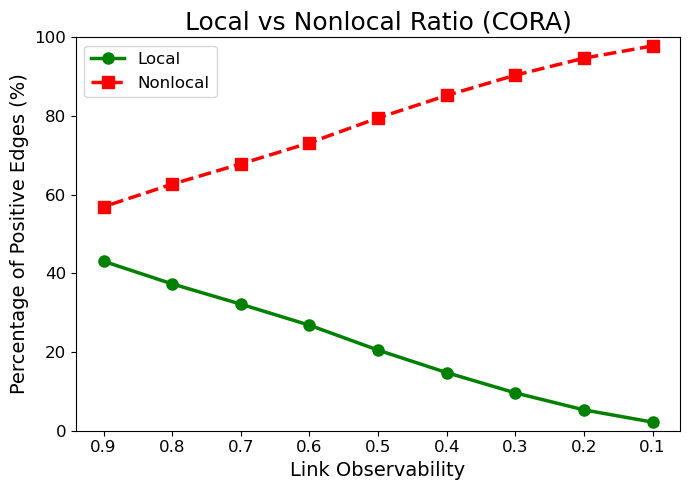

[INFO] Saved: cora_local_ratio.pdf


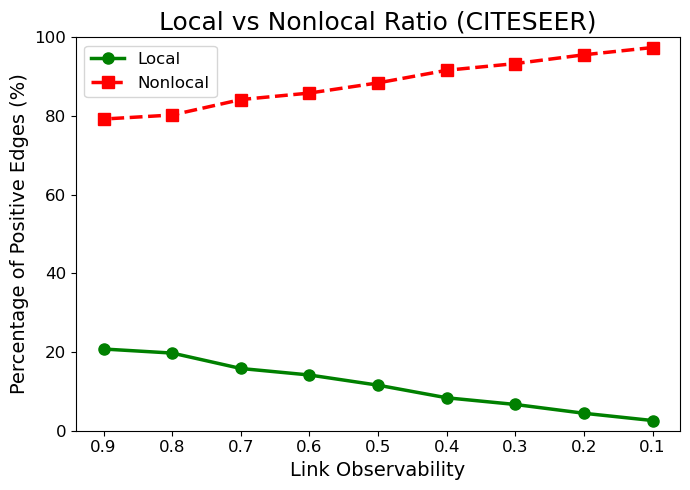

[INFO] Saved: citeseer_local_ratio.pdf


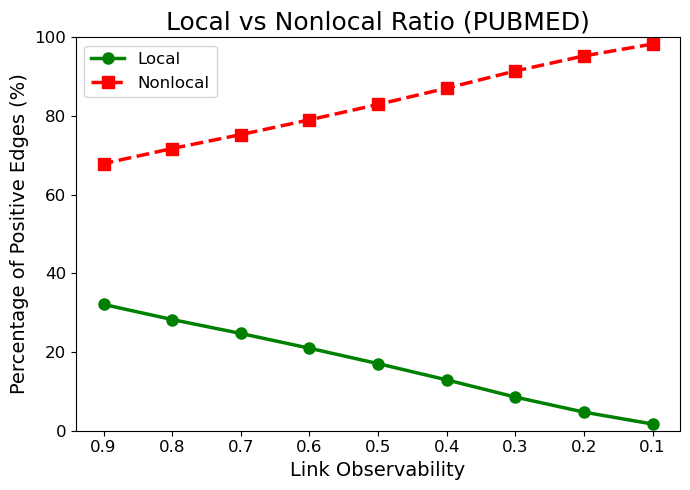

[INFO] Saved: pubmed_local_ratio.pdf


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 默认使用与主图一致的设置

def plot_local_nonlocal_ratio(local_stats):
    """
    local_stats: dict 结构为
        local_stats[(dataset, ratio)] = {
            "local_ratio": float,
            "nonlocal_ratio": float,
            ...
        }
    """
    for dataset in datasets:
        xs, ys_local, ys_nonlocal = [], [], []

        for ratio in split_ticks:
            key = (dataset, ratio)
            if key not in local_stats:
                continue
            info = local_stats[key]
            if "local_ratio" not in info or "nonlocal_ratio" not in info:
                continue

            xs.append(ratio)
            ys_local.append(info["local_ratio"] * 100.0)      # 转百分比
            ys_nonlocal.append(info["nonlocal_ratio"] * 100.0)

        xs = np.array(xs)
        ys_local = np.array(ys_local)
        ys_nonlocal = np.array(ys_nonlocal)

        # 绘图
        plt.figure(figsize=(7, 5))
        plt.title(f"Local vs Nonlocal Ratio ({dataset.upper()})", fontsize=18)
        plt.xlabel("Link Observability", fontsize=14)
        plt.ylabel("Percentage of Positive Edges (%)", fontsize=14)

        plt.xticks(split_ticks)
        plt.tick_params(axis='x', labelsize=12)
        plt.tick_params(axis='y', labelsize=12)
        plt.gca().invert_xaxis()   # 保持与你主图一致的反转 X 轴

        # 排序（按 ratio 升序）
        idx = np.argsort(xs)
        xs, ys_local, ys_nonlocal = xs[idx], ys_local[idx], ys_nonlocal[idx]

        # 绘线
        plt.plot(xs, ys_local,
                 label="Local",
                 color="green",
                 linestyle="-",
                 marker="o",
                 linewidth=2.5,
                 markersize=8)

        plt.plot(xs, ys_nonlocal,
                 label="Nonlocal",
                 color="red",
                 linestyle="--",
                 marker="s",
                 linewidth=2.5,
                 markersize=8)

        plt.ylim(0, 100)
        plt.legend(fontsize=12, loc="best")

        plt.tight_layout()
        out_path = f"{dataset}_local_ratio.pdf"
        plt.savefig(out_path)
        plt.show()
        plt.close()
        print(f"[INFO] Saved: {out_path}")
plot_local_nonlocal_ratio(local_stats)

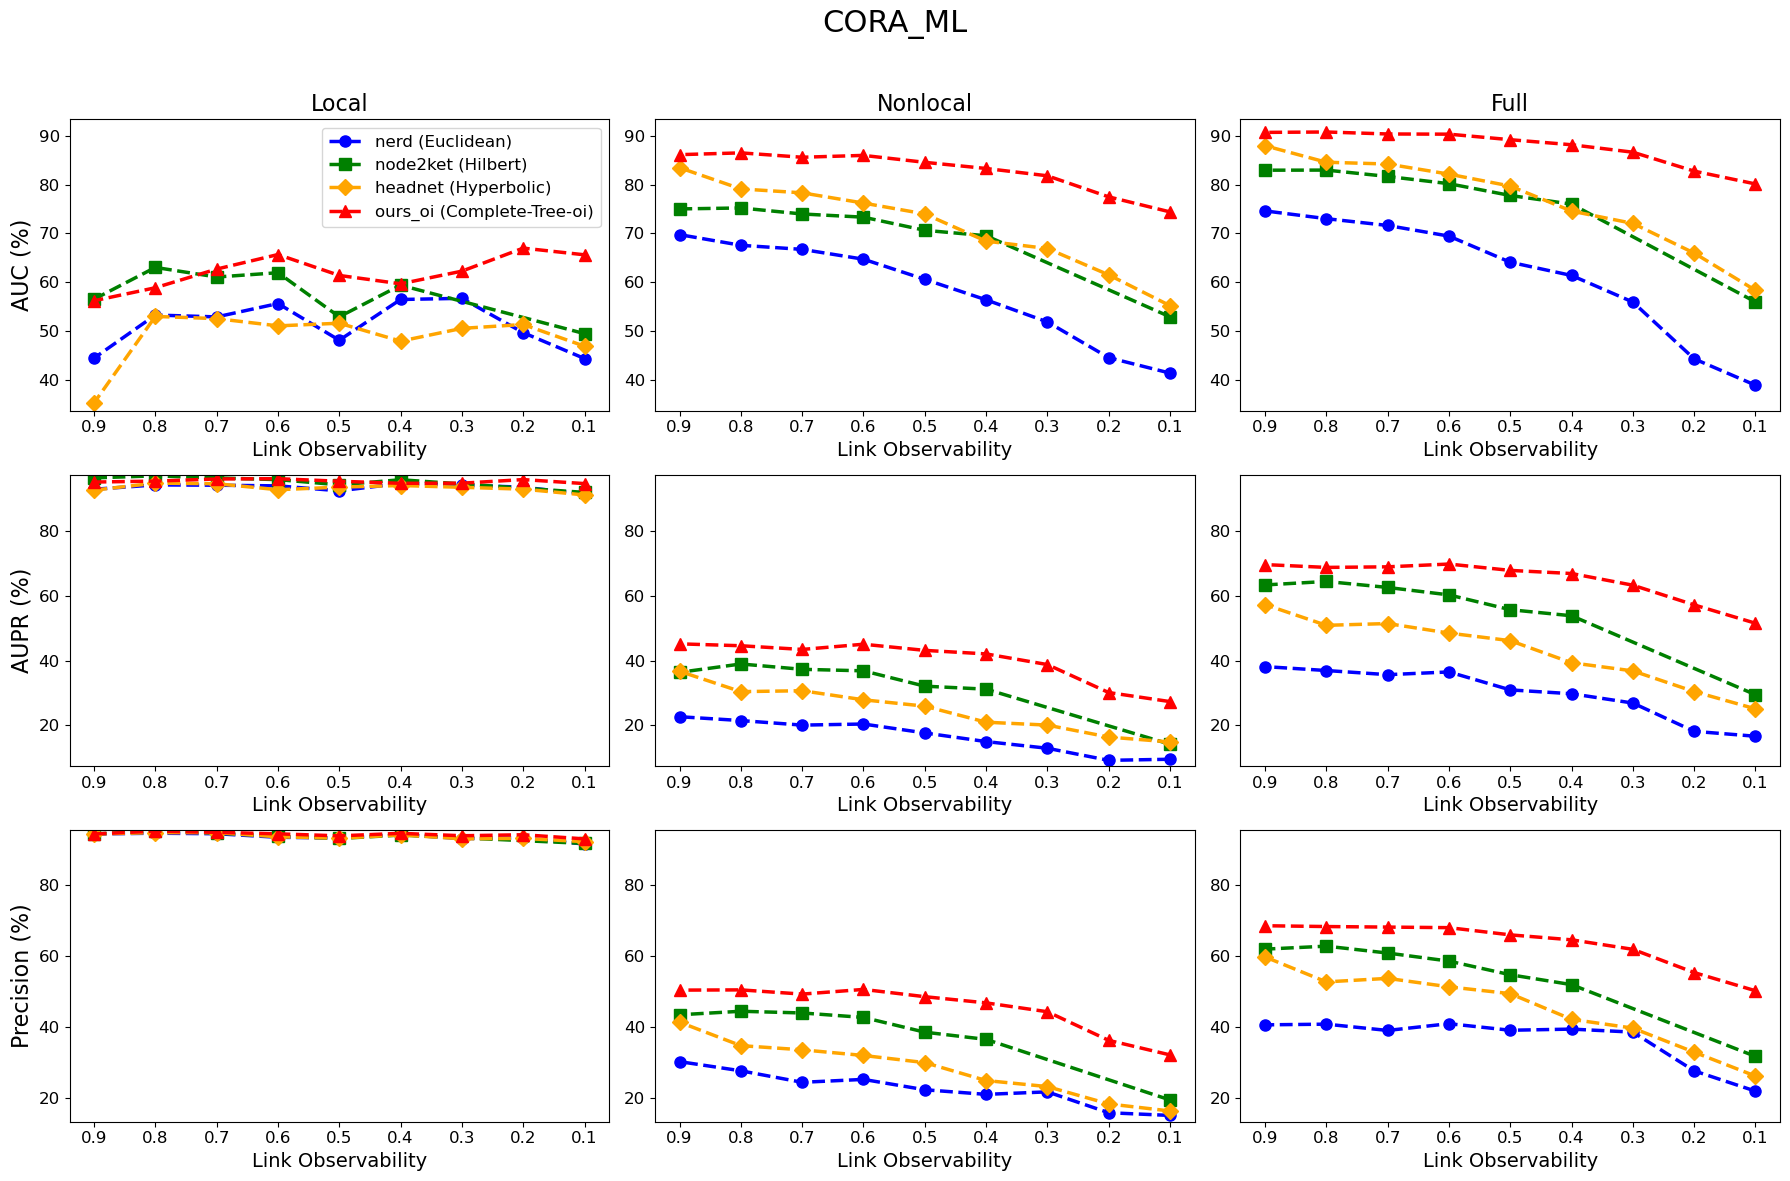

[INFO] Saved: cora_ml_grid_metrics.pdf


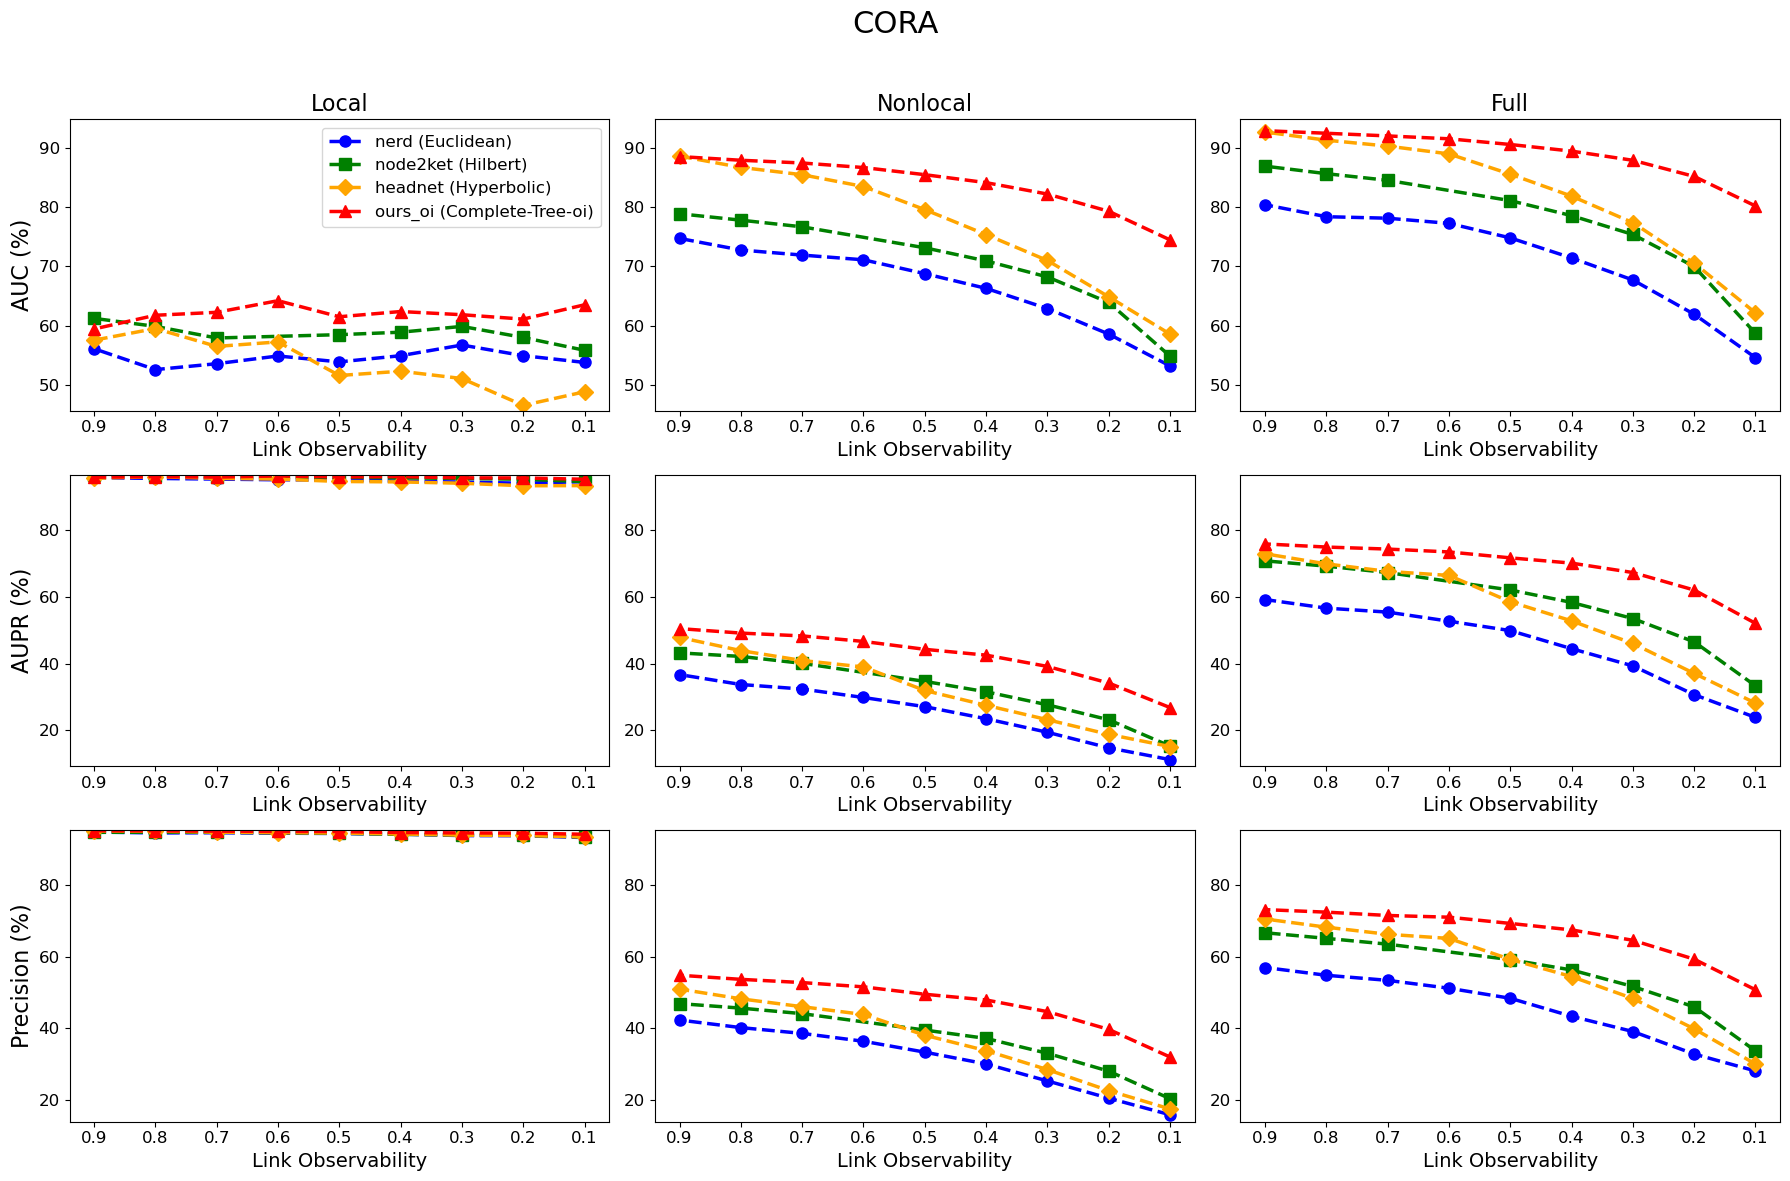

[INFO] Saved: cora_grid_metrics.pdf


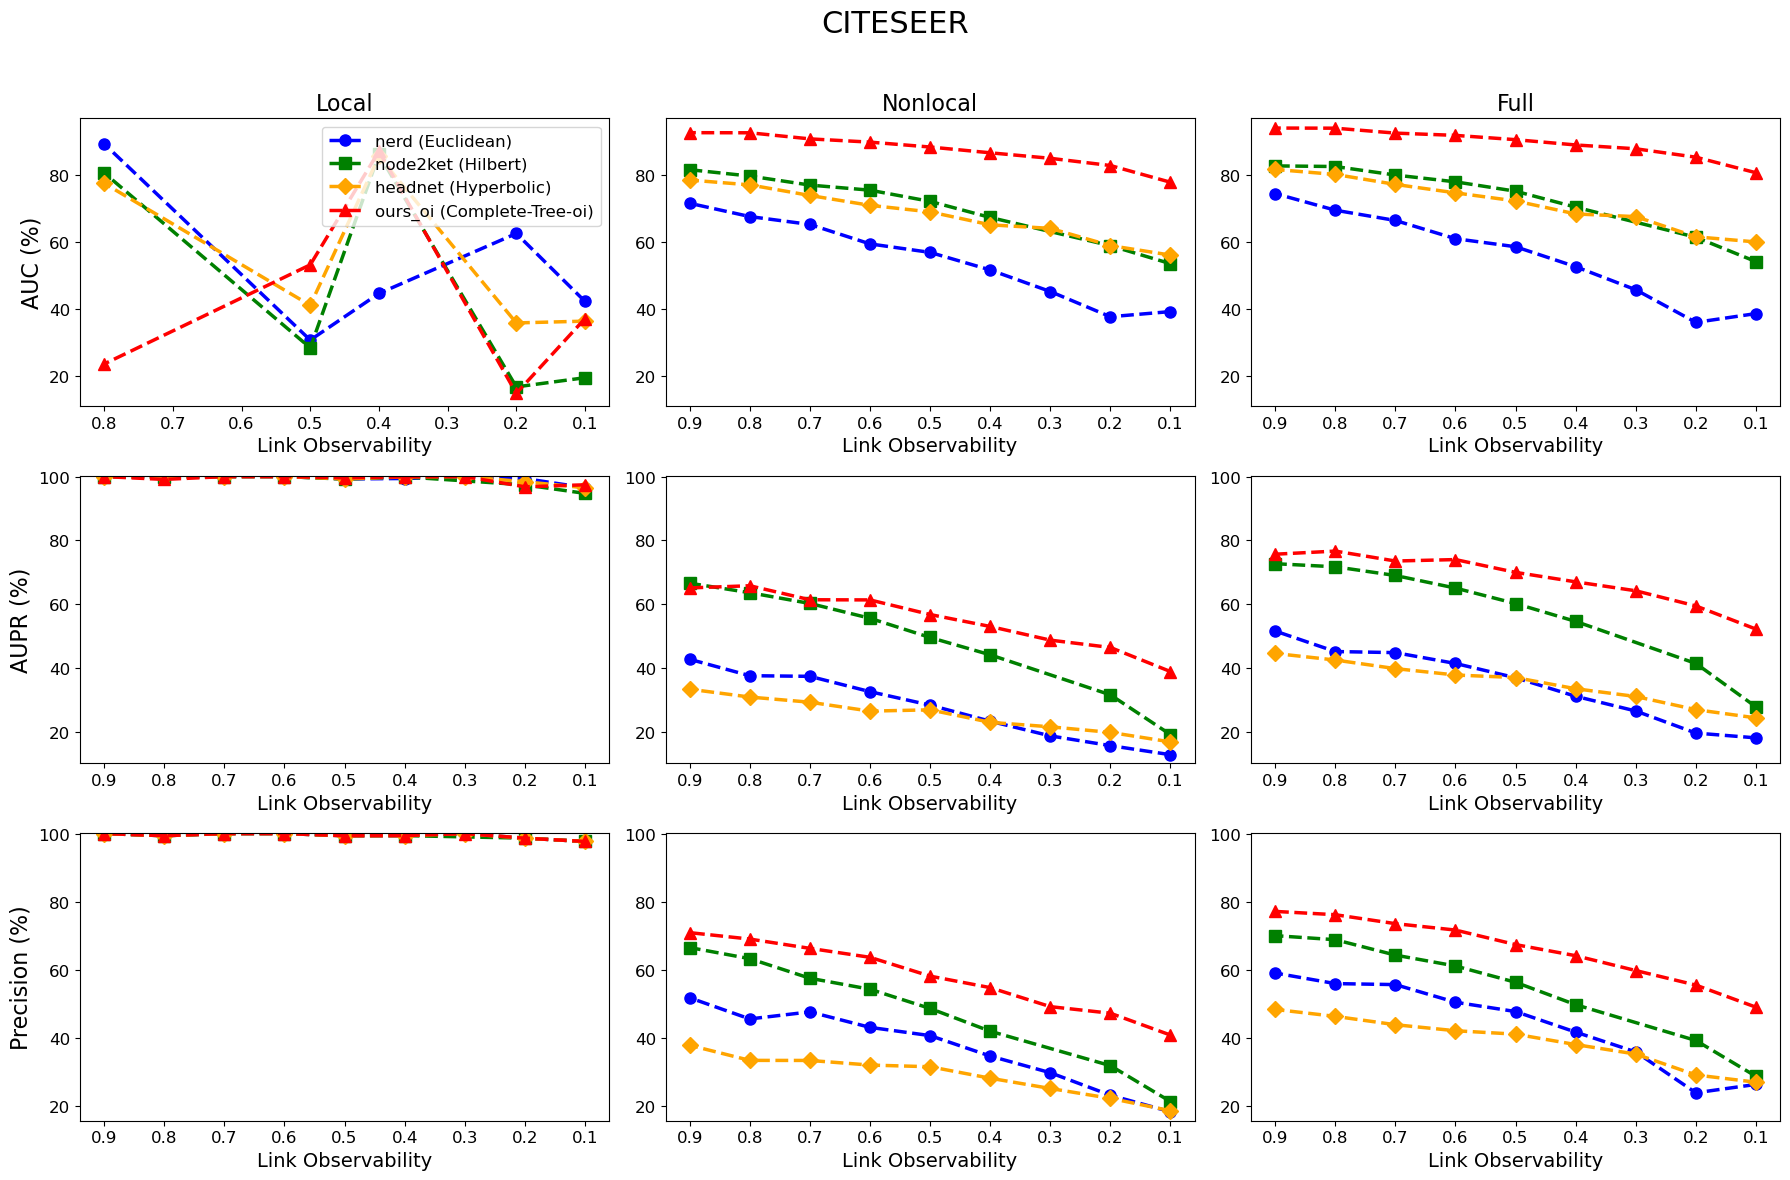

[INFO] Saved: citeseer_grid_metrics.pdf


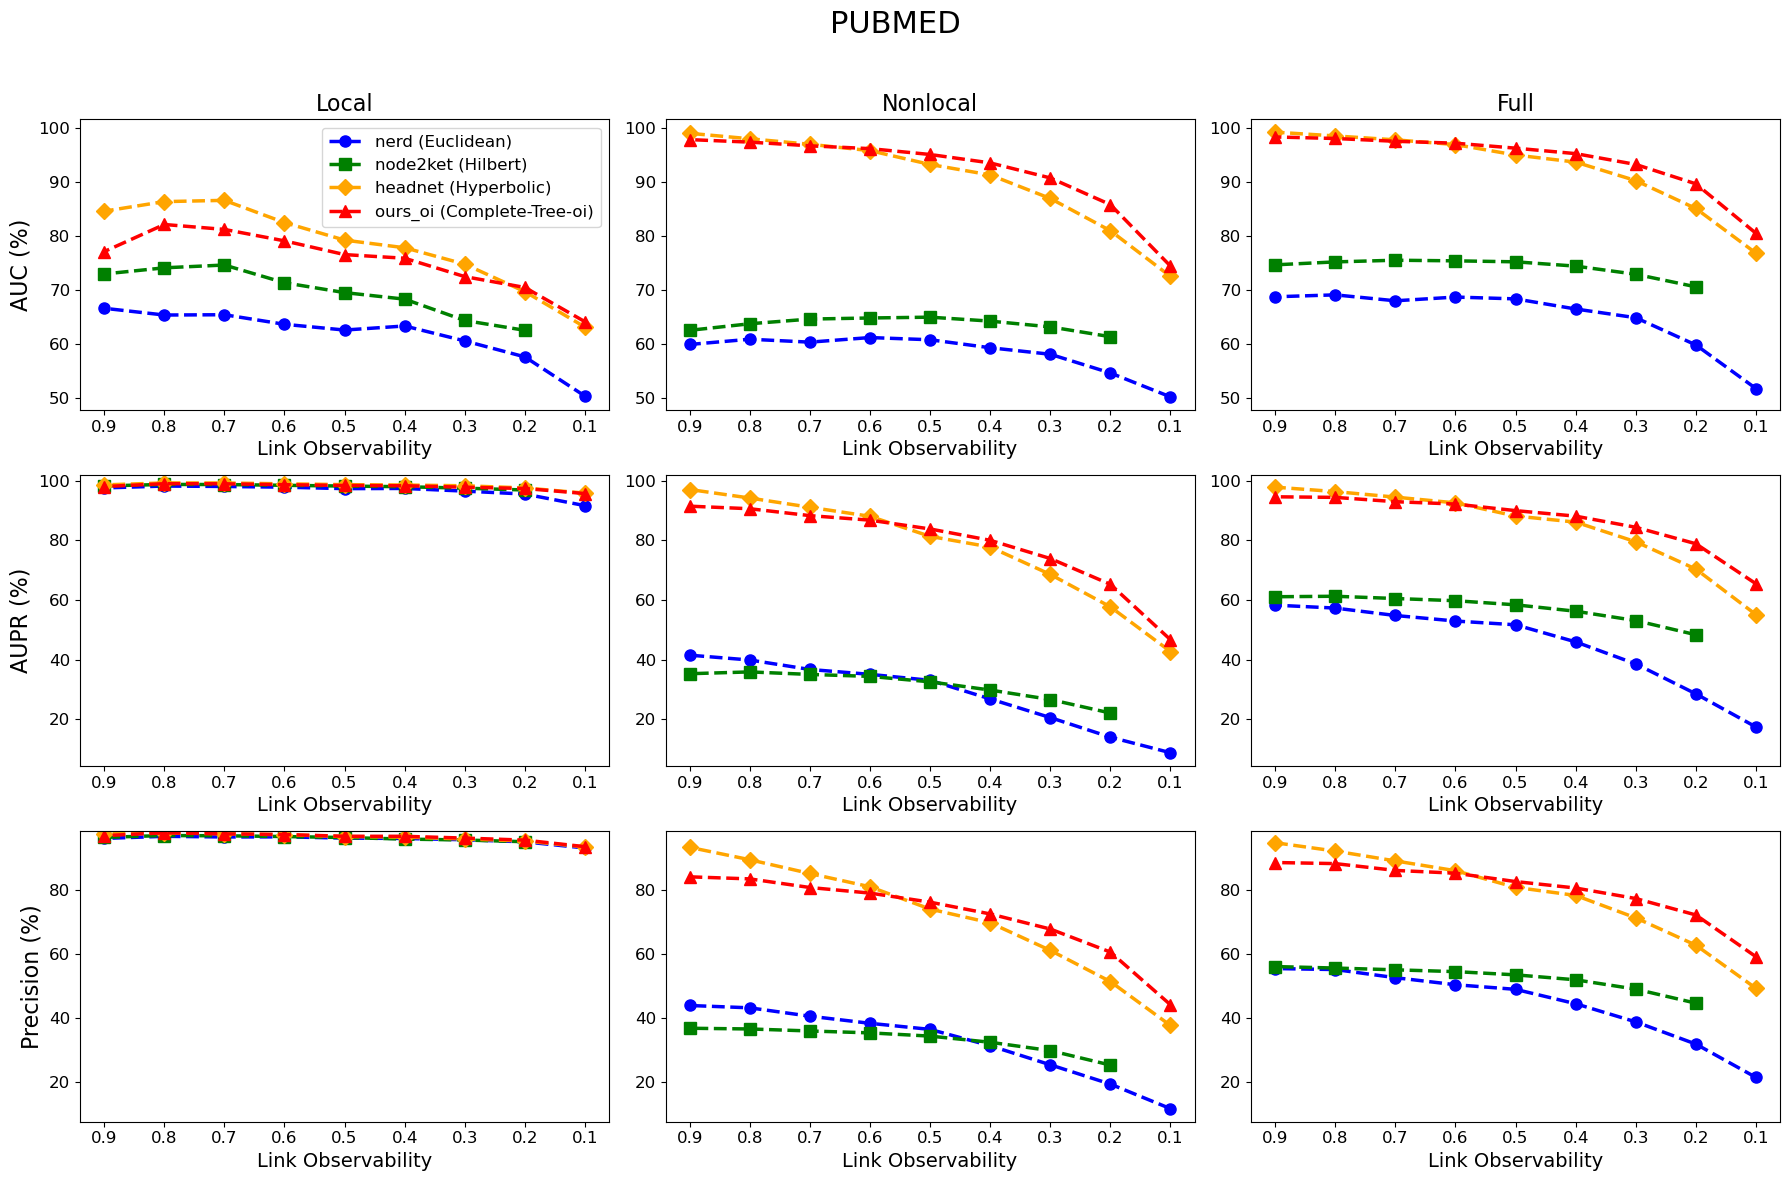

[INFO] Saved: pubmed_grid_metrics.pdf


In [45]:

import numpy as np
import matplotlib.pyplot as plt

# ==============================
#  CONFIG
# ==============================

metrics    = ['auc', 'aupr', 'precision']
subsets    = ['local', 'nonlocal', 'full']
metric_titles = {
    'auc': 'AUC (%)',
    'aupr': 'AUPR (%)',
    'precision': 'Precision (%)'
}

subset_titles = {
    'local': 'Local',
    'nonlocal': 'Nonlocal',
    'full': 'Full'
}


colors      = ['blue', 'green', 'orange', 'red']
line_styles = ['--', '--', '--', '--']
markers     = ['o', 's', 'D', '^']


# ==============================
#  HELPER: extract usable (x,y)
# ==============================

def get_xy(all_results, alg, dataset, subset, metric):
    xs, ys = [], []
    for ratio in split_ticks:
        key = (alg, dataset, ratio)
        if key not in all_results:
            continue
        result_dict = all_results[key]
        if subset not in result_dict:
            continue
        if metric not in result_dict[subset]:
            continue
        val = result_dict[subset][metric]
        if val is None or np.isnan(val):
            continue
        xs.append(ratio)
        ys.append(val * 100.0)   # 转百分比
    return np.array(xs), np.array(ys)


# ==============================
#  MAIN PLOT LOOP
# ==============================

def plot_all_results(all_results):
    """
    all_results: dict 结构为
        all_results[(alg, dataset, ratio)] = {
            "full":     {"auc": ..., "aupr": ..., "precision": ...},
            "local":    {"auc": ..., "aupr": ..., "precision": ...},
            "nonlocal": {"auc": ..., "aupr": ..., "precision": ...}
        }
    """
    for dataset in datasets:
        fig, axes = plt.subplots(3, 3, figsize=(18, 12))
        fig.suptitle(dataset.upper(), fontsize=22, y=0.98)

        for i, metric in enumerate(metrics):
            for j, subset in enumerate(subsets):
                ax = axes[i][j]

                # axis title
                if i == 0:
                    ax.set_title(subset_titles[subset], fontsize=16)

                if j == 0:
                    ax.set_ylabel(metric_titles[metric], fontsize=16)
                    
                # 对数轴
                # ax.set_yscale('log')

                ax.set_xlabel('Link Observability', fontsize=14)
                ax.set_xticks(split_ticks)
                ax.tick_params(axis='x', labelsize=12)
                ax.tick_params(axis='y', labelsize=12)
                ax.invert_xaxis()  # 反转 x 轴

                # plot each algorithm
                for k, alg in enumerate(algorithms):
                    xs, ys = get_xy(all_results, alg, dataset, subset, metric)
                    if len(xs) == 0:
                        continue  # missing -> skip

                    # 排序（按 ratio 升序）
                    idx = np.argsort(xs)
                    xs, ys = xs[idx], ys[idx]

                    ax.plot(
                        xs, ys,
                        label=alg + f" {suffixes[k]}",
                        color=colors[k],
                        linestyle=line_styles[k],
                        linewidth=2.5,
                        marker=markers[k],
                        markersize=8
                    )

            # -------- 统一同一行三个 y 轴范围 --------
            # 取该行三个子图的 y 轴上下界
            row_axes = axes[i]
            y_mins = [ax.get_ylim()[0] for ax in row_axes]
            y_maxs = [ax.get_ylim()[1] for ax in row_axes]
            y_min, y_max = min(y_mins), max(y_maxs)
            for ax in row_axes:
                ax.set_ylim(y_min, y_max)

        #  legend 放在 (0,0) 子图
        axes[0][0].legend(fontsize=12, loc='best')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        out_path = f"{dataset}_grid_metrics.pdf"
        plt.savefig(out_path)
        plt.show()
        plt.close(fig)
        print(f"[INFO] Saved: {out_path}")
    
plot_all_results(all_results)
